In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from datasets import load_dataset
import numpy as np
torch.set_float32_matmul_precision("high")

In [16]:
print(f"XPU available: {hasattr(torch, 'xpu') and torch.xpu.is_available()}")
print(f"CUDA available: {hasattr(torch, 'cuda') and torch.cuda.is_available()}")

XPU available: True
CUDA available: False


In [17]:
def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)

    # 1. calculate dot products QK  
    attention_scores = torch.matmul(query, key.transpose(-2, -1))

    # 2. scale the scores
    attention_scores = attention_scores / math.sqrt(d_k)
    
    # 3. apply mask if given
    if mask is not None:
        attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))
    
    # 4. apply softmax
    attention_weights = F.softmax(attention_scores, dim=-1)

    # 5. apply dropout
    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # 6.  multiply weights by values
    output = torch.matmul(attention_weights, value)

    return output, attention_weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, max_seq_len=512, dropout=0.0, rope_base=10000.0):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        assert self.head_dim % 2 == 0

        self.W_qkv = nn.Linear(d_model, 3 * d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        positions = torch.arange(max_seq_len)
        pair_indices = torch.arange(self.head_dim // 2)
        thetas = rope_base ** ( -2 * pair_indices / self.head_dim)
        angles = positions.unsqueeze(1) * thetas.unsqueeze(0)
        cos = torch.cos(angles).repeat_interleave(2, dim=1) # (max_seq_len, head_dim)
        sin = torch.sin(angles).repeat_interleave(2, dim=1) # (max_seq_len, head_dim)
        self.register_buffer("cos", cos)
        self.register_buffer("sin", sin)    

    def split_heads(self, x):
        B, L, D = x.size()
        x = x.view(B, L, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)
        return x
    
    def combine_heads(self, x):
        B, H, L, Hd = x.size()
        x = x.transpose(1,2).contiguous()
        x = x.view(B, L, H * Hd)
        return x
    
    def rotate_half(self, x):
        t1 = x[..., 0::2]
        t2 = x[..., 1::2]
        return torch.stack([-t2, t1], dim=-1).flatten(start_dim=-2)
    
    def forward(self, x, mask=None, kv_cache=None, start_pos=0):
        qkv = self.W_qkv(x)
        Q, K, V = qkv.chunk(3, dim=-1)

        Q = self.split_heads(Q) # (B, H, L, head_dim)
        K = self.split_heads(K)
        V = self.split_heads(V)

        L = x.size(1)
        cos = self.cos[start_pos:start_pos+L].unsqueeze(0).unsqueeze(0)      # (1, 1, L, head_dim)
        sin = self.sin[start_pos:start_pos+L].unsqueeze(0).unsqueeze(0)

        Q = Q * cos + self.rotate_half(Q) * sin
        K = K * cos + self.rotate_half(K) * sin

        if kv_cache is not None:
            past_k, past_v = kv_cache
            if past_k is not None:
                K = torch.cat([past_k, K], dim=2)
                V = torch.cat([past_v, V], dim=2)
            new_cache = (K, V)
        else:
            new_cache = None

        if mask is not None and mask.dim() == 3:
            mask = mask.unsqueeze(1)
        
        attn_output = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=mask,
            dropout_p=self.dropout.p if self.training else 0.0,
        )
        attn_output = self.combine_heads(attn_output)
        attn_output = self.W_o(attn_output)
        attn_output = self.dropout(attn_output)

        return attn_output, new_cache
    
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_kv_heads=None, max_seq_len=512, dropout=0.0, rope_base=10000.0):
        super().__init__()
        assert d_model%num_heads==0
        if num_kv_heads is  None:
            num_kv_heads = num_heads
        assert num_heads % num_kv_heads == 0
        
        self.d_model      = d_model
        self.num_heads    = num_heads
        self.num_kv_heads = num_kv_heads
        self.n_rep        = num_heads // num_kv_heads
        self.head_dim     = d_model // num_heads
        assert self.head_dim % 2 == 0

        self.q_dim = num_heads * self.head_dim
        self.kv_dim = num_kv_heads * self.head_dim
        self.W_qkv = nn.Linear(d_model, self.q_dim + 2*self.kv_dim)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        positions = torch.arange(max_seq_len)
        pair_indices = torch.arange(self.head_dim // 2)
        thetas = rope_base ** (-2 * pair_indices / self.head_dim)
        angles = positions.unsqueeze(1) * thetas.unsqueeze(0)
        cos = torch.cos(angles).repeat_interleave(2, dim=1)
        sin = torch.sin(angles).repeat_interleave(2, dim=1)
        self.register_buffer("cos", cos)
        self.register_buffer("sin", sin)
    
    def _split(self, x,  num_heads):
        B, L, _ = x.size()
        return x.view(B, L, num_heads, self.head_dim).transpose(1, 2)
    
    def combine_heads(self, x):
        B, H, L, Hd = x.size()
        return x.transpose(1, 2).contiguous().view(B, L, H * Hd)
    
    def rotate_half(self, x):
        t1 = x[..., 0::2]
        t2 = x[..., 1::2]
        return torch.stack([-t2, t1], dim=-1).flatten(start_dim=-2)
    
    def repeat_kv(self, x):
        # (B, G, L, d_h) -> (B, H, L, d_h)
        if self.n_rep == 1:
            return x
        B, G, L, Hd = x.shape
        x = x[:, :, None, :, :].expand(B, G, self.n_rep, L, Hd)
        return x.reshape(B, G * self.n_rep, L, Hd)
    
    def forward(self, x, mask=None, kv_cache=None, start_pos=0):
        B, L, _ = x.size()
        qkv = self.W_qkv(x)
        Q, K, V = torch.split(qkv, [self.q_dim, self.kv_dim, self.kv_dim], dim=-1)
        
        Q = self._split(Q, self.num_heads)
        K = self._split(K, self.num_kv_heads)
        V = self._split(V, self.num_kv_heads)

        cos = self.cos[start_pos:start_pos+L].unsqueeze(0).unsqueeze(0)
        sin = self.sin[start_pos:start_pos+L].unsqueeze(0).unsqueeze(0)
        Q = Q * cos + self.rotate_half(Q) * sin
        K = K * cos + self.rotate_half(K) * sin

        if kv_cache is not None:
            past_k, past_v = kv_cache
            if past_k is not None:
                K = torch.cat([past_k, K], dim=2)
                V = torch.cat([past_v, V], dim=2)
            new_cache = (K, V)
        else:
            new_cache = None

        K = self.repeat_kv(K)
        V = self.repeat_kv(V)

        if mask is not None and mask.dim()==3:
            mask = mask.unsqueeze(1)

        attn_output = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=mask,
            dropout_p=self.dropout.p if self.training else 0.0,
            # enable_gqa=True
        )

        attn_output = self.combine_heads(attn_output)
        attn_output = self.W_o(attn_output)
        attn_output = self.dropout(attn_output)
        return attn_output, new_cache

class MoEFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, num_experts, num_experts_per_tok=2, dropout=0.1):
        super().__init__()
        assert 1 <= num_experts_per_tok <= num_experts
        self.num_experts = num_experts
        self.top_k = num_experts_per_tok
        self.router = nn.Linear(d_model, num_experts, bias=False)
        self.experts = nn.ModuleList([
            SwiGLUFeedForward(d_model, d_ff, dropout) for _ in range(num_experts)
        ])

    def forward(self, x):
        B, L, D = x.shape
        x_flat = x.reshape(B*L, D)  # (N, D)
        N = x_flat.size(0)

        logits = self.router(x_flat)        # (N, E)
        probs = F.softmax(logits, dim=-1)   # (N, E)
        topk_probs, topk_idx = probs.topk(self.top_k, dim=-1)   # (N, k), (N, k)
        topk_probs = topk_probs / topk_probs.sum(-1, keepdim=True)  # (N, k) renormalized

        one_hot = F.one_hot(topk_idx, self.num_experts).float() # (N,k, E)
        P = probs.mean(dim=0)   # (E, ) mean router prob mass
        f = one_hot.sum(dim=(0,1)) / (N * self.top_k)   # (E, ) fraction of router slots
        aux_loss = self.num_experts * torch.sum(f * P)  # scalar, == 1.0at perfect balance

        y = torch.zeros_like(x_flat)    # (N, D)
        mask = one_hot.permute(2, 1, 0).bool()    # (E, k, N)

        for i in range(self.num_experts):
            slot, tok = torch.where(mask[i])
            if tok.numel() == 0:
                continue
            x_i = x_flat[tok]
            h_i = self.experts[i](x_i)
            g_i = topk_probs[tok, slot].to(h_i.dtype)
            y.index_add_(0, tok, (h_i * g_i.unsqueeze(-1)).to(y.dtype))

        return y.reshape(B, L, D), aux_loss

class SwiGLUFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_gate = nn.Linear(d_model, d_ff, bias=False)
        self.w_up   = nn.Linear(d_model, d_ff, bias=False)
        self.w_down = nn.Linear(d_ff, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        gate = F.silu(self.w_gate(x))   # gating signal
        up   = self.w_up(x)             # value path
        x    = gate * up                # elementwise gating
        x    = self.dropout(x)
        x    = self.w_down(x)
        return x

# position-wise feed forward network
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
    
    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x
    
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        in_dtype = x.dtype
        x_fp32 = x.float()
        mean_sq = x_fp32.pow(2).mean(dim=-1, keepdim=True)
        x_fp32 = x_fp32 * torch.rsqrt(mean_sq + self.eps)
        return (x_fp32.to(in_dtype)) * self.weight
    
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, num_kv_heads, d_ff, max_seq_len=512, dropout=0.1, num_experts=None, num_experts_per_tok=2):
        super().__init__()
        self.self_attn = GroupedQueryAttention(d_model, num_heads, num_kv_heads, max_seq_len, dropout)
        
        self.is_moe = num_experts is not None and num_experts > 1
        self.feed_forward = (MoEFeedForward(d_model, d_ff, num_experts, num_experts_per_tok, dropout)
                             if self.is_moe else SwiGLUFeedForward(d_model, d_ff, dropout))

        self.norm1 = RMSNorm(d_model)
        self.norm3 = RMSNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, tgt_mask=None, kv_cache=None, start_pos=0):
        self_attn_input = self.norm1(x)
        self_attn_output, new_cache = self.self_attn(
            x=self_attn_input,
            mask=tgt_mask,
            kv_cache=kv_cache,
            start_pos=start_pos
        )
        x = x + self.dropout1(self_attn_output)

        if self.is_moe:
            ff, aux = self.feed_forward(self.norm3(x))
        else:
            ff, aux = self.feed_forward(self.norm3(x)), None

        x = x + self.dropout3(ff)

        return x, new_cache, aux
    
class Decoder(nn.Module):
    def __init__(self, d_model, num_heads, num_kv_heads, d_ff, n_layer, max_seq_len=512, dropout=0.1, num_experts=None, num_experts_per_tok=2):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, num_kv_heads, d_ff, max_seq_len, dropout, num_experts, num_experts_per_tok) for _ in range(n_layer)])
        self.norm = RMSNorm(d_model)
        mask = torch.tril(torch.ones(max_seq_len, max_seq_len, dtype=torch.bool))
        self.register_buffer("causal_mask", mask)

    def forward(self, x, kv_caches, start_pos=0):
        L = x.size(1)

        tgt_mask = self.causal_mask[:L, :L].unsqueeze(0).unsqueeze(0) if L > 1 else None

        new_caches = []
        aux_total, n_moe = 0.0, 0
        for i, layer in enumerate(self.layers):
            layer_cache = kv_caches[i] if kv_caches is not None else None
            x, new_cache, aux = layer(
                x, 
                tgt_mask=tgt_mask,
                kv_cache=layer_cache,
                start_pos=start_pos
            )
            new_caches.append(new_cache)
            if aux is not None:
                aux_total = aux_total + aux
                n_moe += 1
        aux_mean = aux_total / n_moe if n_moe > 0 else None
        x = self.norm(x)
        return x, new_caches, aux_mean
    
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, n_layer, num_kv_heads=None, dropout=0.1, max_seq_len=512, num_experts=None, num_experts_per_tok=2, aux_coef=0.01):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.aux_coef = aux_coef
        self.wte = nn.Embedding(vocab_size, d_model)
        self.decoder = Decoder(d_model, num_heads, num_kv_heads, d_ff, n_layer, max_seq_len, dropout, num_experts, num_experts_per_tok)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith("W_o.weight") or name.endswith("w_down.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * n_layer))
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, RMSNorm):
            nn.init.ones_(module.weight)
        
    def forward(self, idx, targets=None, kv_caches=None, start_pos=0):
        B, T = idx.size()
        x = self.wte(idx)
        x, new_caches, aux = self.decoder(x, kv_caches=kv_caches, start_pos=start_pos)
        logits = self.lm_head(x)
        
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            if aux is not None:
                loss = loss + self.aux_coef * aux
        return logits, loss, new_caches
    
    @torch.inference_mode()
    def generate(self, tokens, max_tokens, temperature=1.0, top_k=None, seed=42, use_kv_cache=True):
        rng = None
        device = next(self.parameters()).device
        if temperature > 0:
            rng = torch.Generator(device="cpu")
            rng.manual_seed(seed)

        ids = torch.tensor([tokens], dtype=torch.long, device=device)
        n_layer = len(self.decoder.layers)

        def sample(logits):
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            if temperature > 0:
                logits = logits / temperature
                probs = F.softmax(logits, dim=-1).cpu()
                return torch.multinomial(probs, num_samples=1, generator=rng).to(device)
            else:
                return torch.argmax(logits, dim=-1, keepdim=True)

        if use_kv_cache:
            # ---PREFILL---
            empty_caches = [(None, None) for _ in range(n_layer)]
            logits, _, kv_caches = self.forward(ids, kv_caches=empty_caches, start_pos=0)
            logits = logits[:, -1, :]
            cur_pos = ids.size(1)

            for _ in range(max_tokens):
                next_ids = sample(logits)
                yield next_ids.item()

                if cur_pos >= self.max_seq_len:
                    break

                # ---DECODE--- feed only the new token
                logits, _, kv_caches = self.forward(next_ids, kv_caches=kv_caches, start_pos=cur_pos)
                logits = logits[:, -1, :]
                cur_pos += 1
        else:
            # ---NO CACHE--- recompute the full sequence every step
            seq = ids
            for _ in range(max_tokens):
                empty_caches = [(None, None) for _ in range(n_layer)]
                seq_cond = seq[:, -self.max_seq_len:]  # crop to context window
                logits, _, _ = self.forward(seq_cond, kv_caches=empty_caches, start_pos=0)
                logits = logits[:, -1, :]
                next_ids = sample(logits)
                yield next_ids.item()
                seq = torch.cat([seq, next_ids], dim=1)

In [18]:
def get_device():
    if torch.xpu.is_available():
        return "xpu"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"

device = get_device()
batch_size = 8
accumulation_steps = 4
learning_rate = 1e-3

warmup_iters = 300
max_iters = 15000
eval_interval = 10
eval_iters = 20
block_size = 128

def get_lr(it):
    if it < warmup_iters:
        return learning_rate * (it + 1)/ warmup_iters
    progress = (it - warmup_iters)/max(1, max_iters - warmup_iters)
    return learning_rate * 0.5 * (1.0 + math.cos(math.pi*progress)) * 0.9 + learning_rate * 0.1


In [19]:
"""
Preprocess fineweb_edu_small into binary tokenized files.
Streams to disk using a small RAM buffer (2 bytes/token, not 28+).
Outputs train.bin and val.bin in the data directory.
Only processes if files don't already exist.
"""

import numpy as np
from pathlib import Path
from tokenizers import Tokenizer
from datasets import load_dataset
from array import array

# ---------------------------------------------------------------------------
# Portable path resolution: works on any machine, any OS, PC or laptop
# ---------------------------------------------------------------------------
try:
    _ANCHOR = Path(__file__).resolve().parent   # .py script
except NameError:
    _ANCHOR = Path.cwd()                        # Jupyter notebook

# Walk up from the anchor until we find a folder that contains "data/"
PROJECT_ROOT = _ANCHOR
for _parent in [_ANCHOR, *_ANCHOR.parents]:
    if (_parent / "data").exists():
        PROJECT_ROOT = _parent
        break

DATA_DIR       = PROJECT_ROOT / "data" / "fineweb_edu_small"
TOKENIZER_PATH = DATA_DIR / "gpt2_tokenizer" / "tokenizer.json"
TRAIN_PATH     = DATA_DIR / "train.bin"
VAL_PATH       = DATA_DIR / "val.bin"

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")

# ---------------------------------------------------------------------------
# Tokenizer: load if present, otherwise download and save automatically
# ---------------------------------------------------------------------------
if not TOKENIZER_PATH.exists():
    print(f"Tokenizer not found, downloading GPT-2 tokenizer...")
    TOKENIZER_PATH.parent.mkdir(parents=True, exist_ok=True)
    tokenizer = Tokenizer.from_pretrained("gpt2")
    tokenizer.save(str(TOKENIZER_PATH))
    print(f"Saved tokenizer to {TOKENIZER_PATH}")
else:
    tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))
    print(f"Loaded tokenizer from {TOKENIZER_PATH}")

print(f"Vocab size: {tokenizer.get_vocab_size()}")
vocab_size = tokenizer.get_vocab_size()

# ---------------------------------------------------------------------------
# Dataset: only process if bin files do not already exist
# ---------------------------------------------------------------------------
if TRAIN_PATH.exists() and VAL_PATH.exists():
    print(f"\nDataset already exists:")
    print(f"  {TRAIN_PATH}: {TRAIN_PATH.stat().st_size / 1e9:.2f} GB")
    print(f"  {VAL_PATH}: {VAL_PATH.stat().st_size / 1e9:.2f} GB")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    print("\nLoading fineweb_edu_small dataset from Hugging Face...")
    dataset = load_dataset(
        "HuggingFaceFW/fineweb-edu", name="sample-10BT", split="train", streaming=True
    )

    # -----------------------------------------------------------------------
    # Stream all tokens to a temporary binary file (2 bytes per token)
    # -----------------------------------------------------------------------
    TEMP_PATH = DATA_DIR / "all_tokens_temp.bin"
    print(f"\nTokenizing and streaming to temporary file...")
    print(f"(Buffer flushed every 1M tokens to keep RAM usage low)")

    buffer = array('H')          # unsigned short = 2 bytes per token
    flush_every = 1_000_000      # flush every ~2 MB
    total_tokens = 0

    with open(TEMP_PATH, "wb") as f:
        for i, example in enumerate(dataset):
            if i >= 1_000_000:   # limit to first 600k examples
                break

            ids = tokenizer.encode(example["text"]).ids
            ids.append(50256)
            buffer.extend(ids)
            total_tokens += len(ids)

            if len(buffer) >= flush_every:
                buffer.tofile(f)
                buffer = array('H')

            if i % 1000 == 0 and i > 0:
                print(f"  Processed {i:,} examples, {total_tokens:,} tokens")

        # flush remaining tokens
        if buffer:
            buffer.tofile(f)

    print(f"\nTotal tokens: {total_tokens:,}")

    # -----------------------------------------------------------------------
    # Split temp file into train/val using memory mapping (no RAM load)
    # -----------------------------------------------------------------------
    split_idx = int(0.9 * total_tokens)
    print(f"Splitting: {split_idx:,} train | {total_tokens - split_idx:,} val")

    # mmap the temp file read-only
    all_mmap = np.memmap(TEMP_PATH, dtype=np.uint16, mode='r')

    # stream slices directly to final files
    print(f"Writing {TRAIN_PATH.name}...")
    all_mmap[:split_idx].tofile(TRAIN_PATH)

    print(f"Writing {VAL_PATH.name}...")
    all_mmap[split_idx:].tofile(VAL_PATH)

    # cleanup
    del all_mmap
    TEMP_PATH.unlink()

    print("\nDone!")
    print(f"  {TRAIN_PATH}: {TRAIN_PATH.stat().st_size / 1e9:.2f} GB")
    print(f"  {VAL_PATH}: {VAL_PATH.stat().st_size / 1e9:.2f} GB")

Project root : c:\Users\jason\VSProjects\torch
Data dir     : c:\Users\jason\VSProjects\torch\data\fineweb_edu_small
Loaded tokenizer from c:\Users\jason\VSProjects\torch\data\fineweb_edu_small\gpt2_tokenizer\tokenizer.json
Vocab size: 50257

Dataset already exists:
  c:\Users\jason\VSProjects\torch\data\fineweb_edu_small\train.bin: 1.86 GB
  c:\Users\jason\VSProjects\torch\data\fineweb_edu_small\val.bin: 0.21 GB


In [20]:
print(f"Vocab size: {vocab_size}")

# Memmap means we never load the whole file into RAM. Reads are lazy.
train_data = np.memmap(DATA_DIR / "train.bin", dtype=np.uint16, mode="r")
val_data   = np.memmap(DATA_DIR / "val.bin",   dtype=np.uint16, mode="r")
print(f"train tokens: {len(train_data):,}, val tokens: {len(val_data):,}")

def get_batch(split, batch_size, block_size, device):
    data = train_data if split == "train" else val_data
    # Sample random starting positions. We need block_size+1 tokens per sample
    # so we can build x[:block_size] and y[1:block_size+1].
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i      : i+block_size  ].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1    : i+block_size+1].astype(np.int64)) for i in ix])
    if device != "cpu":
        # pinning + non_blocking gives a small speedup on GPU/XPU
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

Vocab size: 50257
train tokens: 928,578,464, val tokens: 103,175,385


In [21]:
model = GPT(
    vocab_size=vocab_size,
    d_model=128,
    num_heads=4,
    num_kv_heads=4,
    n_layer=2,
    d_ff=512,
    dropout=0.0,
    max_seq_len=256,
    num_experts=8,
    num_experts_per_tok=2
).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Parameters: 9.71M


In [22]:
model = model.to(device)

decay_params    = [p for n, p in model.named_parameters() if p.dim() >= 2]
nondecay_params = [p for n, p in model.named_parameters() if p.dim() < 2]

optimizer = torch.optim.AdamW([
    {'params': decay_params,    'weight_decay': 0.1},
    {'params': nondecay_params, 'weight_decay': 0.0},
], lr=learning_rate, betas=(0.9, 0.95))

scaler = torch.amp.GradScaler(device=device)

accumulation_steps = 4
fflosses        = []
ffavg_val_losses = []

for iter_num in range(max_iters):
    # lr schedule
    lr = get_lr(iter_num)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    # gradient accumulation
    model.train()
    optimizer.zero_grad(set_to_none=True)
    accum_loss = 0.0

    for micro_step in range(accumulation_steps):
        x, y = get_batch("train", batch_size, block_size, device)
        with torch.autocast(device_type=device, dtype=torch.float16):
            _, loss, _ = model(x, y)
        loss = loss / accumulation_steps
        scaler.scale(loss).backward()
        accum_loss += loss.item()

    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()
    fflosses.append(accum_loss)

    # eval
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        model.eval()
        expert_counts = {}
        def make_hook(name):
            def hook(module, inp, out):
                x = inp[0].reshape(-1, inp[0].size(-1))
                _, ti = F.softmax(module.router(x).float(), -1).topk(module.top_k, -1)
                c = torch.bincount(ti.flatten(), minlength=module.num_experts).float().cpu()
                expert_counts[name] = expert_counts.get(name, 0) + c
            return hook
        hooks = [m.register_forward_hook(make_hook(n))
                 for n, m in model.named_modules() if isinstance(m, MoEFeedForward)]
        with torch.no_grad():
            val_losses = []
            for _ in range(eval_iters):
                x, y = get_batch("val", batch_size, block_size, device)
                with torch.autocast(device_type=device, dtype=torch.float16):
                    _, val_loss, _ = model(x, y)
                val_losses.append(val_loss.item())
        for h in hooks:
            h.remove()

        avg_val_loss = sum(val_losses) / len(val_losses)
        ffavg_val_losses.append(avg_val_loss)
        print(f"Iter {iter_num}: Train Loss {accum_loss:.4f}, Val Loss {avg_val_loss:.4f}",
              flush=True)

        # per-layer utilization: fraction of routed slots landing on each expert
        for name, c in expert_counts.items():
            frac = c / c.sum()
            starving = int((frac < 0.02).sum())   # < ~1/6 of fair share for E=8
            print(f"    {name}: " + " ".join(f"{p:.2f}" for p in frac.tolist())
                  + f"   (min {frac.min():.3f}, max {frac.max():.2f}, starving {starving})",
                  flush=True)

Iter 0: Train Loss 10.8754, Val Loss 10.8675
    decoder.layers.0.feed_forward: 0.14 0.10 0.17 0.14 0.13 0.08 0.10 0.15   (min 0.081, max 0.17, starving 0)
    decoder.layers.1.feed_forward: 0.12 0.16 0.13 0.12 0.09 0.12 0.18 0.08   (min 0.083, max 0.18, starving 0)
Iter 10: Train Loss 10.8304, Val Loss 10.8264
    decoder.layers.0.feed_forward: 0.14 0.10 0.18 0.13 0.11 0.08 0.10 0.15   (min 0.082, max 0.18, starving 0)
    decoder.layers.1.feed_forward: 0.10 0.13 0.15 0.15 0.08 0.15 0.17 0.07   (min 0.071, max 0.17, starving 0)
Iter 20: Train Loss 10.7410, Val Loss 10.7146
    decoder.layers.0.feed_forward: 0.13 0.10 0.19 0.14 0.10 0.08 0.09 0.17   (min 0.078, max 0.19, starving 0)
    decoder.layers.1.feed_forward: 0.08 0.08 0.19 0.16 0.07 0.17 0.20 0.05   (min 0.047, max 0.20, starving 0)
Iter 30: Train Loss 10.5210, Val Loss 10.5160
    decoder.layers.0.feed_forward: 0.13 0.09 0.23 0.13 0.07 0.06 0.08 0.21   (min 0.064, max 0.23, starving 0)
    decoder.layers.1.feed_forward: 0.02 

KeyboardInterrupt: 

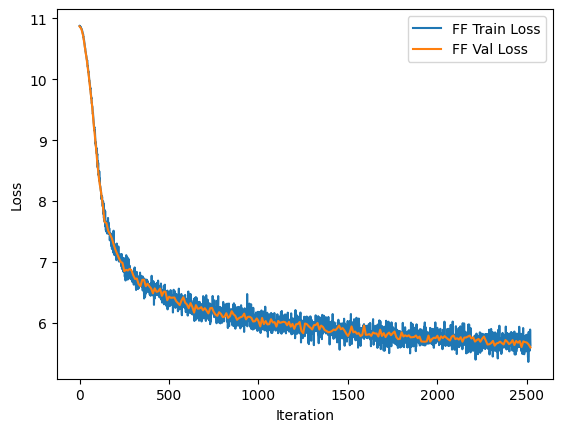

In [25]:
# plot
import matplotlib.pyplot as plt
# # Plot training losses
# plt.plot(losses, label="Mixture of Experts Train Loss")
# # Plot validation losses (mapped across training iterations)
# plt.plot(np.linspace(0, len(losses)-1, len(avg_val_losses)), avg_val_losses, label="Val Loss")
    
# Plot second model's training losses
plt.plot(fflosses, label="FF Train Loss")
# Plot second model's validation losses
plt.plot(np.linspace(0, len(fflosses)-1, len(ffavg_val_losses)), ffavg_val_losses, label="FF Val Loss")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()
# Save the model
torch.save(model.state_dict(), "gpt_model.pth")

In [50]:
ckpt = torch.load("gpt_model.pth", map_location=device, weights_only=True)
loaded_model = GPT(
    vocab_size=vocab_size,
    d_model=128,
    num_heads=4,
    num_kv_heads=4,
    n_layer=2,
    d_ff=512,
    dropout=0.0,
    max_seq_len=256,
    num_experts=8,
    num_experts_per_tok=2
).to(device)
loaded_model.load_state_dict(ckpt)
loaded_model.eval()

prompt = "The mitochondria is"
prompt_tokens = tokenizer.encode(prompt).ids

print(f"\nPrompt: {prompt!r}")
print("Generated: ", end="", flush=True)
print(prompt, end="", flush=True)

import time

counter = 0
start = time.perf_counter()

for token in loaded_model.generate(
    prompt_tokens, max_tokens=150, temperature=0.8, top_k=50, seed=89754, use_kv_cache=False
):
    print(tokenizer.decode([token]), end="", flush=True)
    counter += 1
end = time.perf_counter()
print(f"\nInference Speed w/out KV-cache: {counter/(end-start):.6f} tok/s")

start_kv = time.perf_counter()

for token in loaded_model.generate(
    prompt_tokens, max_tokens=150, temperature=0.8, top_k=50, seed=89754,
):
    print(tokenizer.decode([token]), end="", flush=True)
end_kv = time.perf_counter()
print(f"\nInference Speed w/ KV-cache: {counter/(end_kv-start_kv):.6f} tok/s")


Prompt: 'The mitochondria is'
Generated: The mitochondria is the most common of the most common and very closely related.
This is a natural solution for a small piece of natural or red, the other is not a major component of their own, but may not be a type of other type of metal and the different from a small number of shapes, along with a constant color of the lower and of the base, it can also be used for a type of one type of the body and have a less than a day.
When you are using a circuit used, the two and are made of a tiny light, which may be used for a simple method. For a few problems, it is the best used in the process.
When the patient is not used, it is possible to perform a
Inference Speed w/out KV-cache: 19.838922 tok/s
 the most common of the most common and very closely related.
This is a natural solution for a small piece of natural or red, the other is not a major component of their own, but may not be a type of other type of metal and the different from a small numb

50 tokens
No KV:   12.523475 tok/s
With KV: 15.438120 tok/s
100 tokens
No KV:   11.714643 tok/s
With KV: 15.989614 tok/s
150 tokens
No KV:   16.246370 tok/s
With KV: 28.113545 tok/s
200 tokens
No KV:   19.159714 tok/s
With KV: 27.203378 tok/s
250 tokens
No KV:   15.503982 tok/s
With KV: 18.144934 tok/s
300 tokens
No KV:   11.243480 tok/s
With KV: 19.162433 tok/s
350 tokens
No KV:   15.710987 tok/s
With KV: 21.444151 tok/s
400 tokens
No KV:   11.058926 tok/s
With KV: 16.300053 tok/s


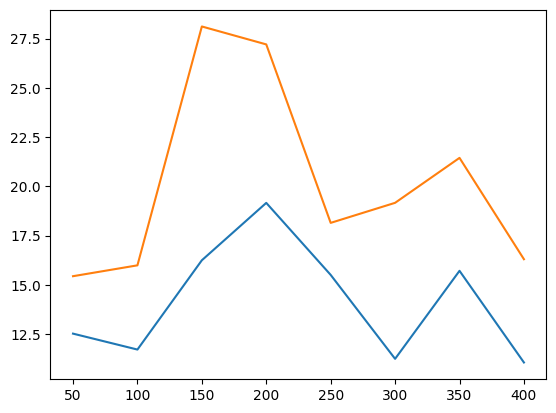

In [49]:
ckpt = torch.load("gpt_model.pth", map_location=device, weights_only=True)
loaded_model = GPT(
    vocab_size=vocab_size,
    d_model=128,
    num_heads=4,
    num_kv_heads=4,
    n_layer=2,
    d_ff=512,
    dropout=0.0,
    max_seq_len=256,
    num_experts=8,
    num_experts_per_tok=2
).to(device)
loaded_model.load_state_dict(ckpt)
loaded_model.eval()

prompt = "Taylor Swift is the"
prompt_tokens = tokenizer.encode(prompt).ids

def run_generation(**kwargs):
    tokens = []
    start = time.perf_counter()
    for token in loaded_model.generate(prompt_tokens, **kwargs):
        tokens.append(token)
    end = time.perf_counter()
    return tokens, end-start

lengths = torch.linspace(50, 400, 8, dtype=torch.int64)
speed = []
kv_speed = []
for l in lengths:
    tokens_no_kv, t = run_generation(max_tokens=l, temperature=0.8, top_k=50, seed=89754, use_kv_cache=False)
    tokens_kv, t_kv = run_generation(max_tokens=l, temperature=0.8, top_k=50, seed=89754, use_kv_cache=True)
    speed.append(len(tokens_no_kv)/t)
    kv_speed.append(len(tokens_kv)/t_kv)
    print(f"{l} tokens")
    print(f"No KV:   {len(tokens_no_kv)/t:.6f} tok/s")
    print(f"With KV: {len(tokens_kv)/t_kv:.6f} tok/s")
plt.plot(lengths, speed)
plt.plot(lengths, kv_speed)